## Aireado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Definición de ruta
file_path = '../../data/raw/dataset_aireado.csv'

if os.path.exists(file_path):
    df_raw = pd.read_csv(file_path)
    print(f"Dataset cargado exitosamente. Formato: {df_raw.shape}")
else:
    print("Error: El archivo no existe en la ruta especificada.")

# Asegurar orden temporal para los lags
df_raw = df_raw.sort_values(['run_id', 'time_min'])

df_raw.head()


Dataset cargado exitosamente. Formato: (30000, 11)


,run_id,time_min,T_amb,T_set,fault_id,Kg_embutido,N_fan_Hz,T_cab,RH_cab,T_evap_sat,P_comp_W
0,0,0,22.045572,14.0,0,686.902155,41.054036,14.378606,68.955243,6.378606,1004.046095
1,0,1,21.348400,14.0,0,686.902155,42.509123,14.899510,72.891073,6.899510,964.436032
2,0,2,24.143944,14.0,0,686.902155,49.648057,14.686181,70.022304,6.686181,1056.216648
3,0,3,22.633919,14.0,0,686.902155,53.290981,14.905184,69.104901,6.905184,1080.669963
4,0,4,19.974857,14.0,0,686.902155,58.247170,14.930055,66.747719,6.930055,1106.247901


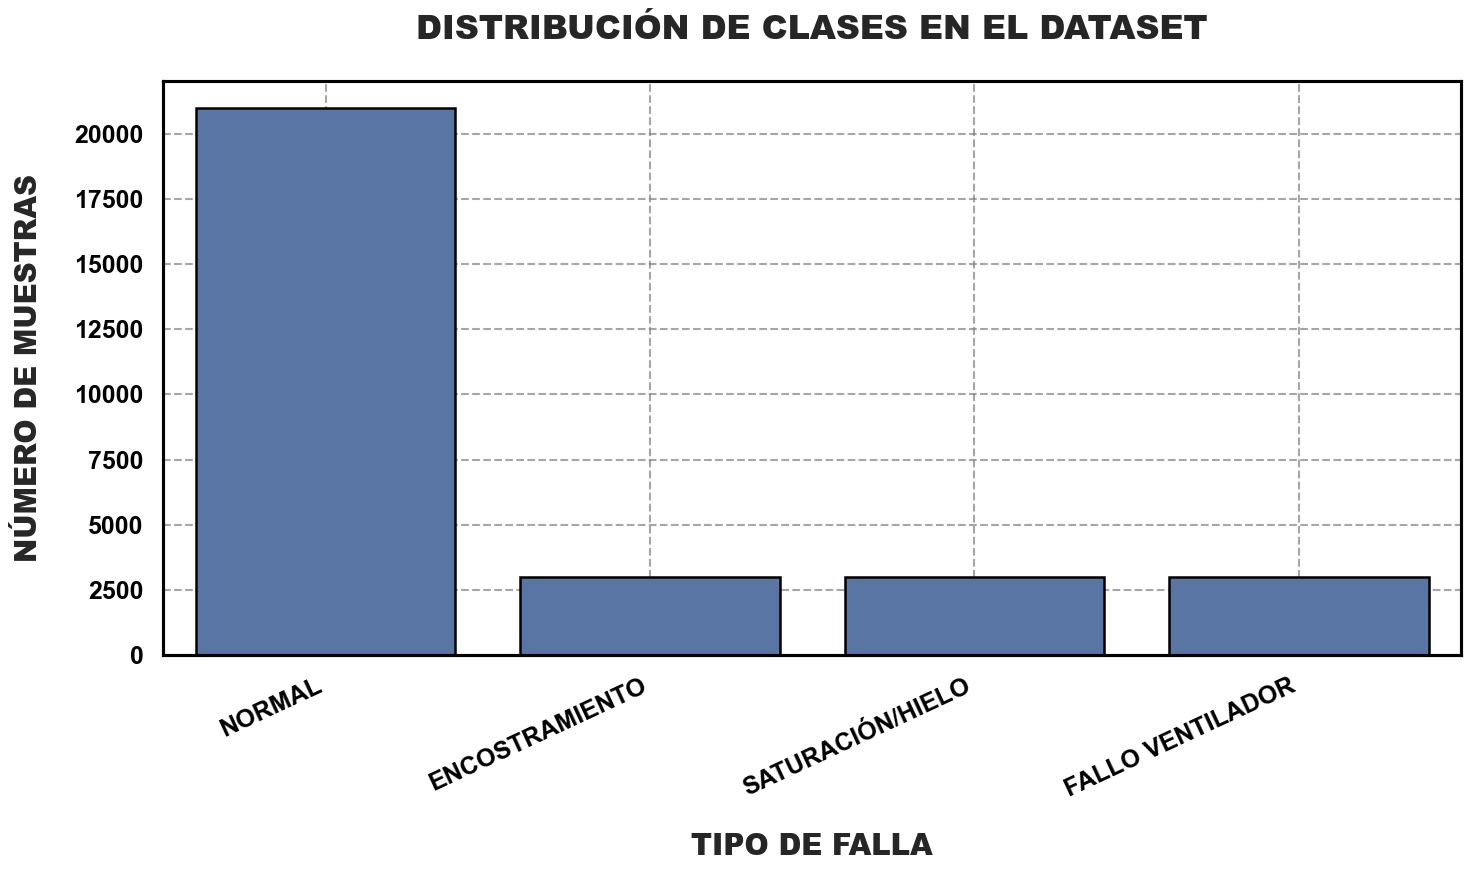

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de alta resolución para evitar difuminado
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# 2. Estilo con Grid completa y marco cerrado
sns.set_theme(style="whitegrid") # Proporciona el grid de fondo
plt.figure(figsize=(10, 6))

target_names = ['NORMAL', 'ENCOSTRAMIENTO', 'SATURACIÓN/HIELO', 'FALLO VENTILADOR']

# 3. Crear el gráfico
# Eliminamos las anotaciones sobre las barras y cerramos el marco
ax = sns.countplot(
    data=df_raw, 
    x='fault_id', 
    edgecolor='black', # Borde negro sólido para las barras
    linewidth=1.2
)

# 4. Cerrar el marco de la figura (Spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

# 5. Configuración de Ticks (Grandes y Nítidos)
ax.set_xticks(range(len(target_names)))
ax.set_xticklabels(
    target_names, 
    rotation=25, 
    ha='right', 
    fontsize=12, 
    fontweight='bold', 
    color='black'
)

plt.yticks(fontsize=12, fontweight='bold', color='black')

# 6. Etiquetas y Título
ax.set_xlabel('TIPO DE FALLA', fontsize=14, fontweight='black', labelpad=15)
ax.set_ylabel('NÚMERO DE MUESTRAS', fontsize=14, fontweight='black', labelpad=15)
plt.title('DISTRIBUCIÓN DE CLASES EN EL DATASET', fontsize=16, fontweight='black', pad=20)

# Ajustar rejilla para que sea sutil pero visible
ax.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True) # Pone el grid detrás de las barras

plt.tight_layout()
plt.show()

<Axes: xlabel='RH_cab', ylabel='Count'>

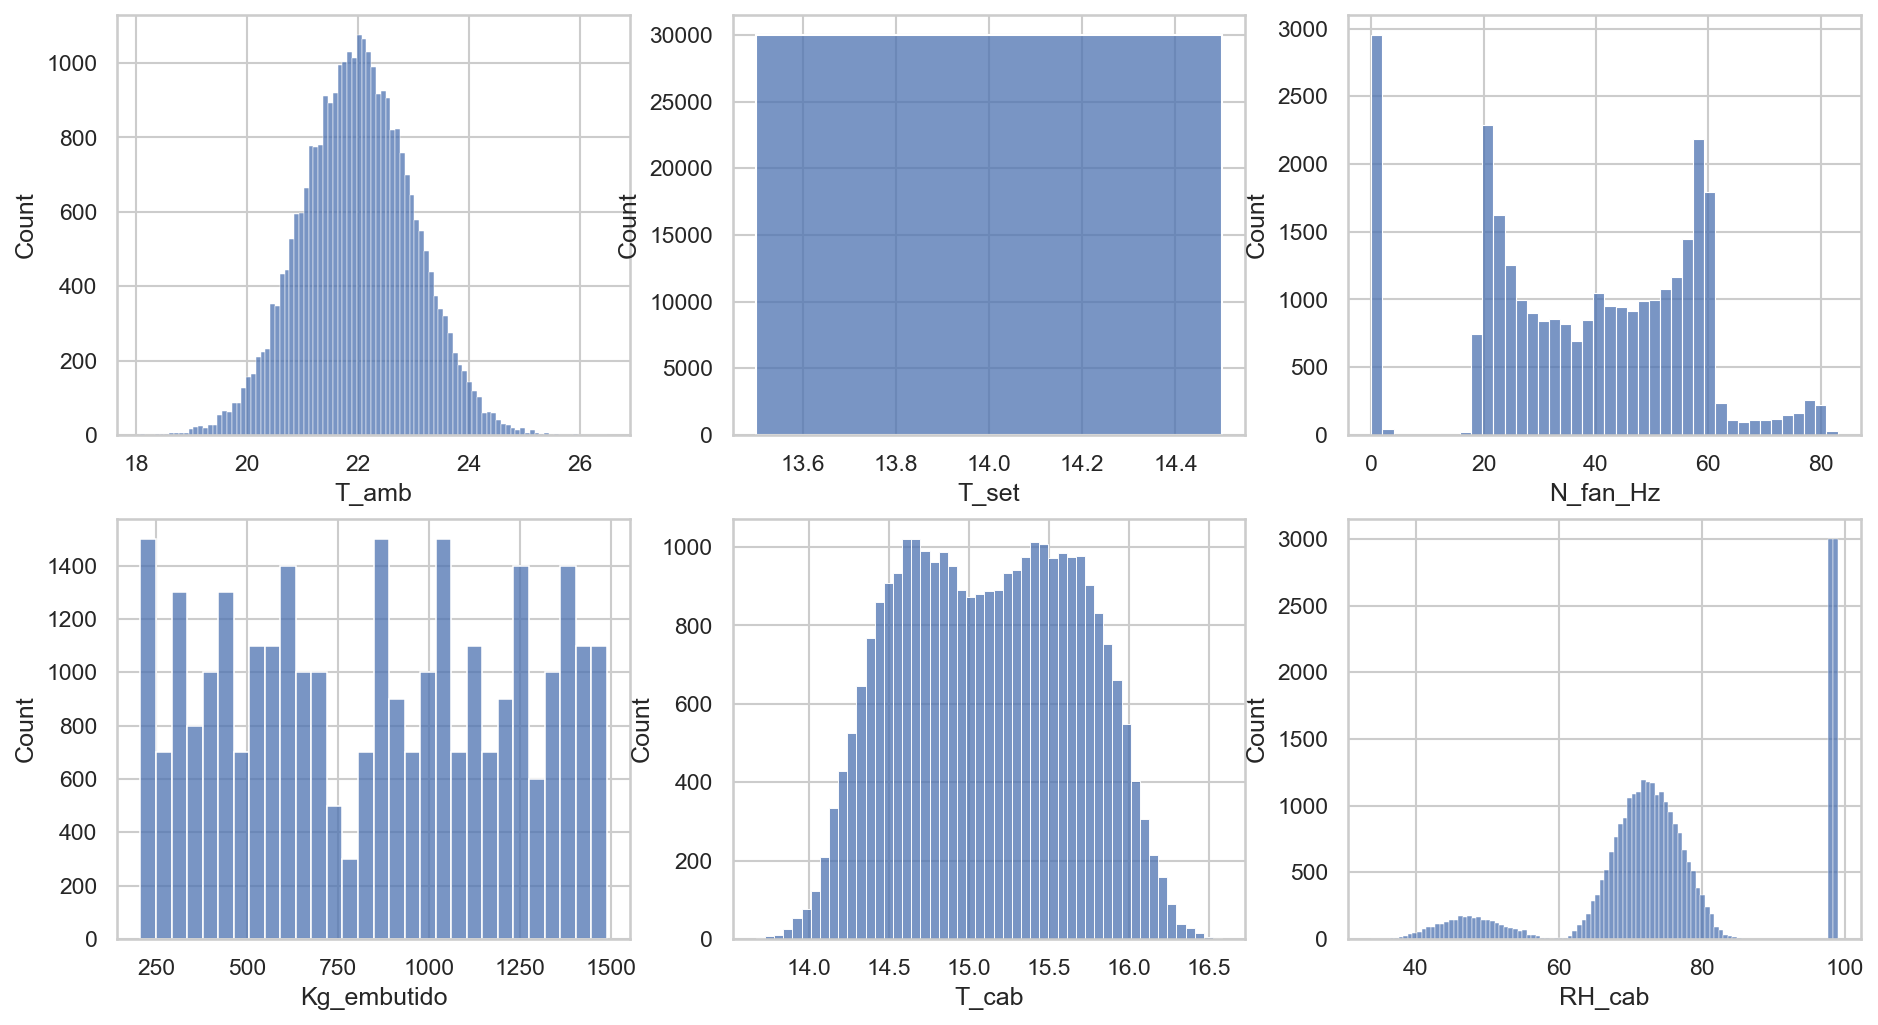

In [20]:
#Distributions of features (with histograms)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(data=df_raw, x='T_amb', ax=axes[0, 0])
sns.histplot(data=df_raw, x='T_set', ax=axes[0, 1])
sns.histplot(data=df_raw, x='N_fan_Hz', ax=axes[0, 2])
sns.histplot(data=df_raw, x='Kg_embutido', ax=axes[1, 0])
sns.histplot(data=df_raw, x='T_cab', ax=axes[1, 1])
sns.histplot(data=df_raw, x='RH_cab',ax=axes[1, 2] )





--- Ranking de Correlación Lineal con fault_id ---
RH_cab         0.609926
Kg_embutido    0.023078
T_cab          0.018042
T_amb          0.003883
P_comp_W      -0.212832
N_fan_Hz      -0.436453
T_evap_sat    -0.451244
Name: fault_id, dtype: float64


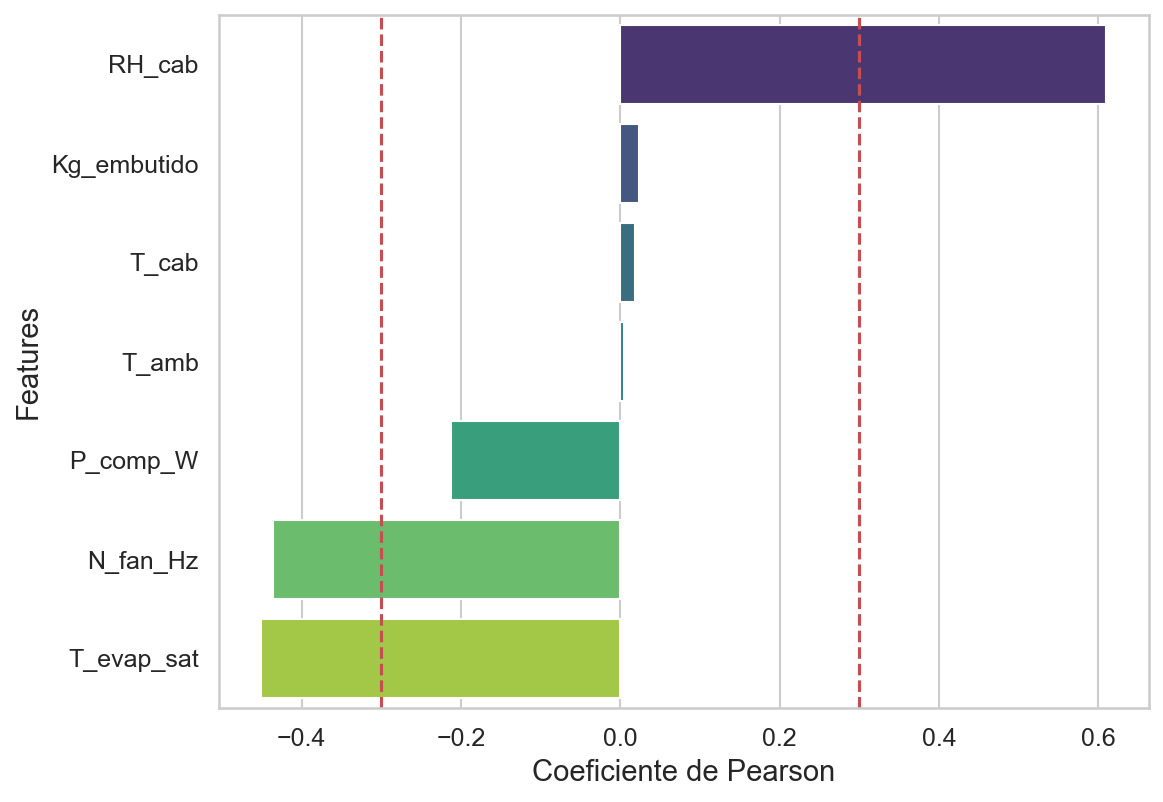

In [21]:
# 1. Calcular la matriz de correlación solo para números
corr_matrix = df_raw.select_dtypes(include='number').corr()

# 2. Extraer la correlación de todas las columnas con 'fault_id'
# Usamos .abs() porque una correlación de -0.8 es tan importante como una de +0.8
fault_corr = corr_matrix['fault_id'].drop(['fault_id', 'run_id', 'T_set', 'time_min']).sort_values(ascending=False)

# 3. Mostrar el ranking
print("--- Ranking de Correlación Lineal con fault_id ---")
print(fault_corr)


plt.figure(figsize=(8, 6))

ax = sns.barplot(x=fault_corr.values, y=fault_corr.index, hue=fault_corr.index, palette='viridis', legend=False)


ax.set_xlabel('Coeficiente de Pearson', fontsize=14)
ax.set_ylabel('Features', fontsize=14)

ax.tick_params(axis='both', labelsize=12) 



plt.axvline(x=0.3, color='r', linestyle='--', label='Umbral 0.3')
plt.axvline(x=-0.3, color='r', linestyle='--')
plt.show()

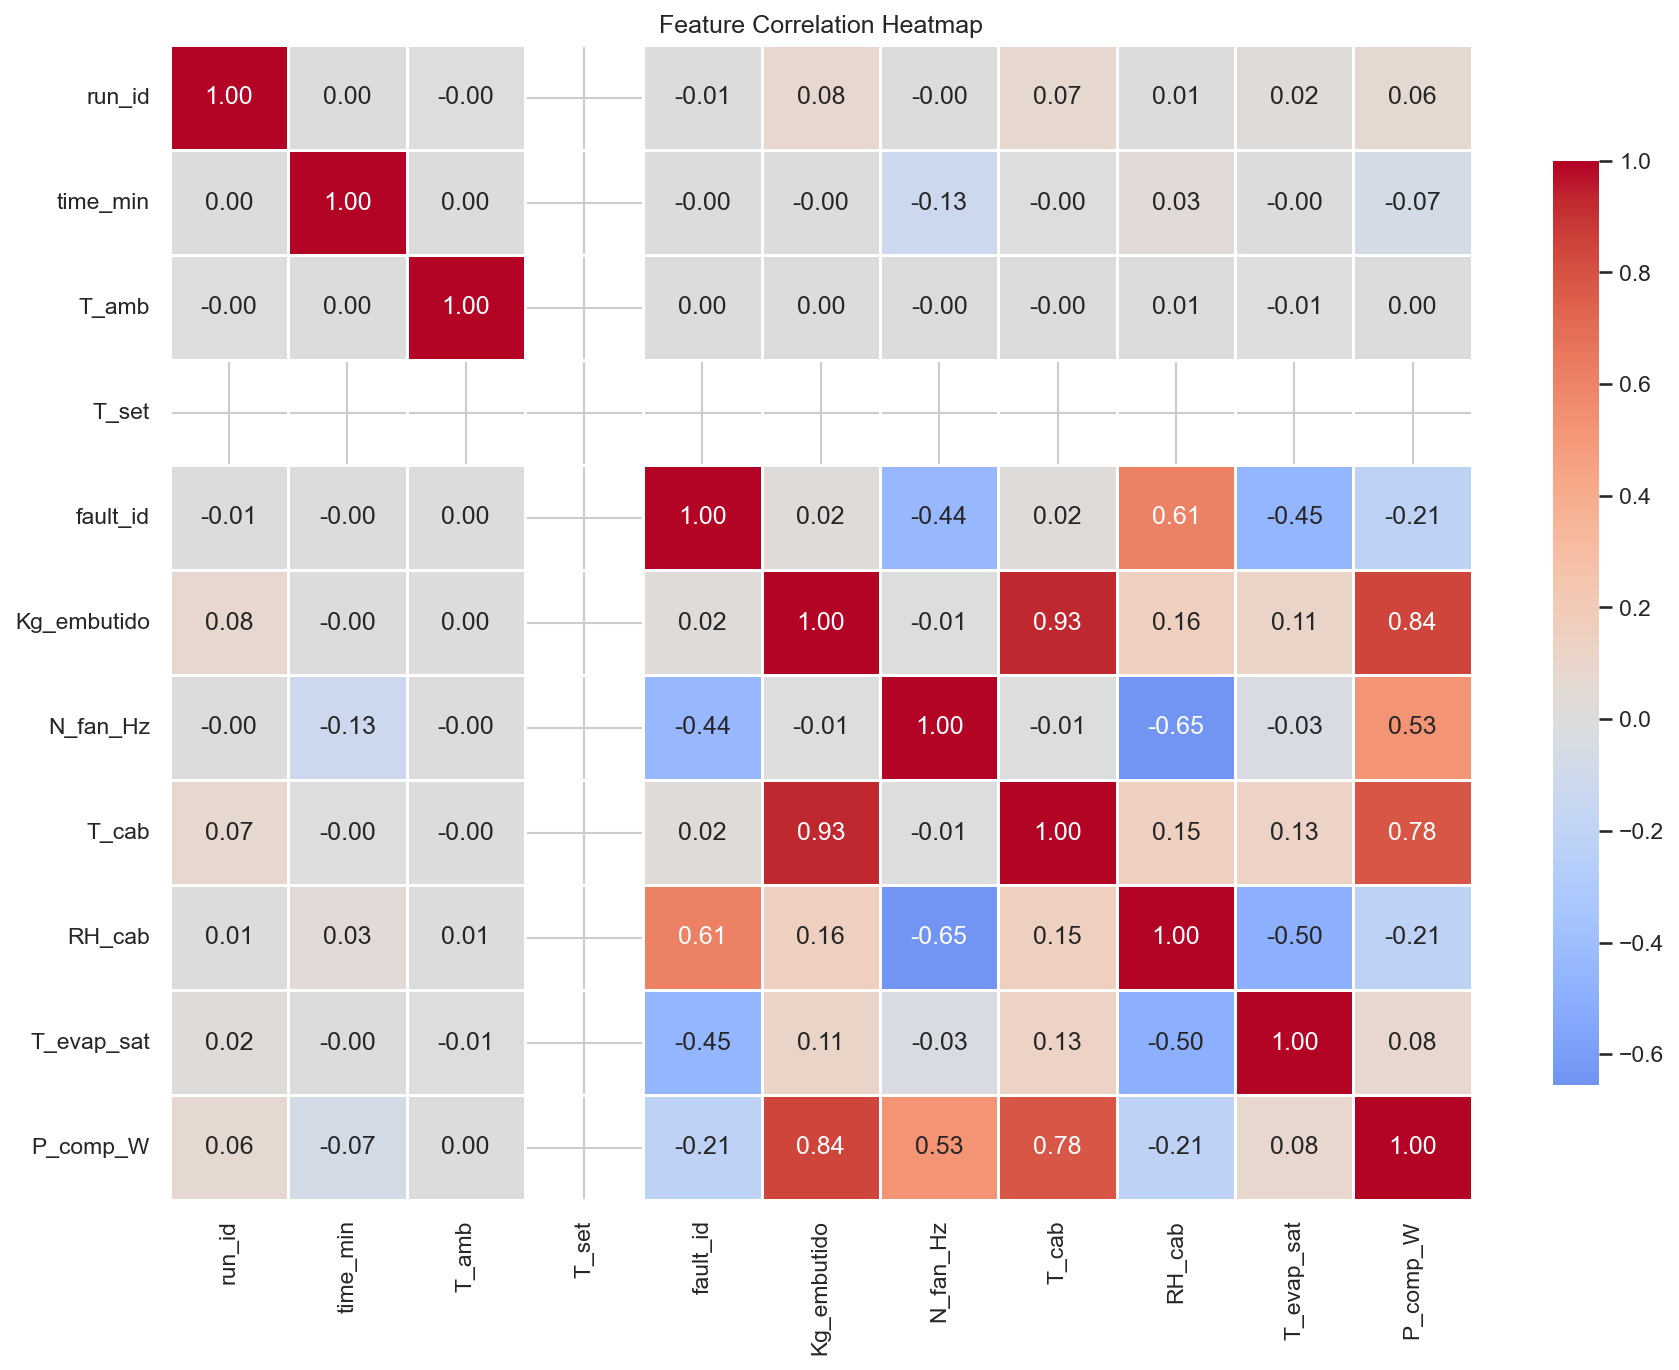

In [22]:
#Correlation Heatmap
plt.figure(figsize=(14, 10))

core_cols = df_raw.select_dtypes(include='number').columns
corr = df_raw[core_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap')
plt.show()

In [23]:
def extract_aireado_features(df):
    df_ext = df.copy()
    
    # 1. Delta Higroscópico (Referencia: Ruiz-Ramirez, 2005)
    # Diferencia respecto a la humedad de equilibrio teórica
    df_ext['RH_error'] = df_ext['RH_cab'] - 75.0 
    
    # 2. Ratio Aire/Carga (Referencia: Imre, 1974)
    # Evalúa si el flujo de aire es suficiente para la masa de embutido
    df_ext['Air_Flow_Ratio'] = df_ext['N_fan_Hz'] / (df_ext['Kg_embutido'] + 1.0)
    
    # 3. Eficiencia de Evaporación (Referencia: Andrés et al., 2007)
    # Relación entre enfriamiento y deshumidificación
    df_ext['Evap_Eff_Index'] = (df_ext['T_cab'] - df_ext['T_evap_sat']) / (df_ext['RH_cab'] + 0.1)
    
    # 4. Potencia Específica por Carga (Referencia: Toldrá, 2006)
    # Energía consumida por cada Kg de producto fresco
    df_ext['Specific_Power_Load'] = df_ext['P_comp_W'] / (df_ext['Kg_embutido'] + 1.0)
    
    # 5. Indicador de Encostramiento (Predictor de Falla 1)
    # Aire alto + RH baja = Riesgo de Case Hardening
    df_ext['Encostramiento_Risk'] = df_ext['N_fan_Hz'] / (df_ext['RH_cab'] + 1.0)

    return df_ext

df_phys = extract_aireado_features(df_raw)

In [24]:
def inject_test_noise(X_test_df, noise_level):
    """
    Añade ruido gaussiano y picos de error al set de test para simular
    sensores reales de planta.
    """
    X_noisy = X_test_df.copy()
    
    for col in X_noisy.columns:
        # Añadimos ruido gaussiano (fluctuación de señal)
        scale = X_noisy[col].std() * noise_level
        if scale > 0:
            X_noisy[col] += np.random.normal(0, scale, X_noisy.shape[0])
            
        # Añadimos 'Spikes' (1 de cada 100 lecturas falla totalmente)
        mask = np.random.rand(len(X_noisy)) < 0.01
        X_noisy.loc[mask, col] *= np.random.choice([0.8, 1.2]) 
        
    return X_noisy

In [25]:
def create_aireado_lags(df, features, lags):
    df_lagged = df.copy()
    for feat in features:
        for lag in lags:
            # Valor previo del sensor
            df_lagged[f"{feat}_lag_{lag}"] = df_lagged.groupby("run_id")[feat].shift(lag)
            # TENDENCIA: Delta de cambio (Crucial para ver si el secado se estanca)
            df_lagged[f"{feat}_delta_{lag}"] = df_lagged[feat] - df_lagged[f"{feat}_lag_{lag}"]
    
    # Rolling mean para suavizar ciclos de ventilación periódica (Imre, 1974)
    df_lagged['RH_roll_mean_20'] = df_lagged.groupby('run_id')['RH_cab'].transform(lambda x: x.rolling(20, min_periods=5).mean())
    
    return df_lagged

# Aplicamos a variables críticas
features_to_lag = ['RH_cab', 'T_cab', 'N_fan_Hz', 'Evap_Eff_Index']
lags_aireado = [10, 30, 60]

df_final = create_aireado_lags(df_phys, features_to_lag, lags_aireado)

# Limpieza de NaNs generados por lags
df_final = df_final.dropna()
print(f"Dataset final listo para entrenamiento: {df_final.shape}")

Dataset final listo para entrenamiento: (12000, 41)


In [26]:
# Separación de características y objetivo
target = 'fault_id'
features = [col for col in df_final.columns if col not in ['run_id', 'time_min', 'fault_id']]

X = df_final[features]
y = df_final[target]

# Split temporal respetando los runs (80% entrenamiento, 20% test)
unique_runs = df_final['run_id'].unique()
train_runs, test_runs = train_test_split(unique_runs, test_size=0.2, random_state=42)

X_train = df_final[df_final['run_id'].isin(train_runs)][features]
y_train = df_final[df_final['run_id'].isin(train_runs)][target]
X_test = df_final[df_final['run_id'].isin(test_runs)][features]
y_test = df_final[df_final['run_id'].isin(test_runs)][target]



In [27]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Definir el espacio de búsqueda de hiperparámetros
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}


unique_runs = df_final['run_id'].unique()
train_val_runs, test_runs = train_test_split(unique_runs, test_size=0.2, random_state=42)

df_train_val = df_final[df_final['run_id'].isin(train_val_runs)]
df_test = df_final[df_final['run_id'].isin(test_runs)]

# 2. Configurar Cross-Validation (5-Folds) sobre el resto (80%)
# Usamos GroupKFold para que un "run_id" nunca esté en train y val a la vez.
gkf = GroupKFold(n_splits=5)
X_tv = df_train_val[features]
y_tv = df_train_val[target]
groups = df_train_val['run_id']

#scaler = StandardScaler()
# Solo fit con X_train_val para evitar data leakage
#X_tv_scaled = scaler.fit_transform(X_tv) 

# Guardar artefactos
#joblib.dump(scaler, 'models/artifacts/scaler_aireado.pkl')

# 3. Configurar la búsqueda aleatoria (RandomizedSearch)
# Usamos 10 iteraciones para no tardar demasiado, evaluando con GroupKFold
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=5, 
    cv=gkf,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_weighted'
)

# 4. Ejecutar el Tuning sobre el set de Entrenamiento/Validación
print("--- INICIANDO HYPERPARAMETER TUNING CON GROUP-K-FOLD ---")
# IMPORTANTE: Pasamos 'groups' para que RandomizedSearch sepa cómo separar los runs

rf_random_search.fit(X_tv, y_tv, groups=groups)

# 5. Extraer el mejor modelo
rf_aireado = rf_random_search.best_estimator_
#GUARDAMOS ARTEFACTOS
joblib.dump(rf_aireado, 'models/artifacts/rf_aireado.pkl')

print(f"\nMejores parámetros encontrados: {rf_random_search.best_params_}")
print(f"Mejor F1-Score en CV: {rf_random_search.best_score_:.4f}")

--- INICIANDO HYPERPARAMETER TUNING CON GROUP-K-FOLD ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Mejores parámetros encontrados: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Mejor F1-Score en CV: 1.0000


In [28]:
# Mapeo descriptivo para los ejes
target_mapping = {
    0: 'NORMAL', 
    1: 'ENCOSTRAMIENTO', 
    2: 'SATURACIÓN/HIELO', 
    3: 'FALLO VENTILADOR'
}


def apply_neurosymbolic_aireado(df_phys, y_pred, mapping):
    """Capa 1 de Post-proceso: Corrección por leyes físicas."""
    y_final = y_pred.copy()
    ids = {name: i for i, name in mapping.items()}
    
    # Regla: Riesgo físico de encostramiento por exceso de ventilación/baja HR
    limit_enc = df_phys['Encostramiento_Risk'].quantile(0.90)
    y_final[(df_phys['Encostramiento_Risk'] > limit_enc) & (df_phys['RH_cab'] < 68)] = 1
    
    # Regla: Fallo de ventilador (Hz cerca de cero pero modelo dice OK)
    y_final[(df_phys['N_fan_Hz'] < 5.0) & (y_pred == 0)] = 3
    
    return y_final

y_test_ns = apply_neurosymbolic_aireado(df_test, y_test, target_mapping)

In [29]:
def apply_run_voting(df, y_pred):
    df_temp = df.copy()
    df_temp['y_pred'] = y_pred
    
    # Consenso por ciclo de funcionamiento
    run_votes = df_temp.groupby('run_id')['y_pred'].transform(
        lambda x: x.value_counts().idxmax()
    )
    return run_votes.values

# Predicciones
y_pred_pure = rf_aireado.predict(X_test)
# Obtenemos el df de test original para mapear run_id

y_pred_voted = apply_run_voting(df_test, y_pred_pure)

# Resultados
print("--- REPORTE DE CLASIFICACIÓN (AIREADO + VOTO) ---")
print(classification_report(y_test, y_pred_voted))

--- REPORTE DE CLASIFICACIÓN (AIREADO + VOTO) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1720
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       200
           3       1.00      1.00      1.00       280

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



In [30]:


y_pred_clean = rf_aireado.predict(X_test)
y_voted_clean = apply_run_voting(df_test, y_pred_clean)
y_pred_final = apply_run_voting(df_test, y_test_ns)

X_test_noisy = inject_test_noise(X_test, noise_level=0.90) # 10% de ruido
y_pred_noisy = rf_aireado.predict(X_test_noisy)

# 3. APLICAR VOTO SOBRE DATOS RUIDOSOS
# Aquí es donde el Voto por Run demuestra su valor filtrando los spikes
y_voted_noisy = apply_run_voting(df_test, y_pred_noisy)



print("--- RESULTADOS TRAS STRESS TEST (5% RUIDO) ---")
print(classification_report(y_test, y_voted_noisy, target_names=target_mapping.values()))

--- RESULTADOS TRAS STRESS TEST (5% RUIDO) ---
                  precision    recall  f1-score   support

          NORMAL       1.00      1.00      1.00      1720
  ENCOSTRAMIENTO       1.00      1.00      1.00       200
SATURACIÓN/HIELO       1.00      1.00      1.00       200
FALLO VENTILADOR       1.00      1.00      1.00       280

        accuracy                           1.00      2400
       macro avg       1.00      1.00      1.00      2400
    weighted avg       1.00      1.00      1.00      2400



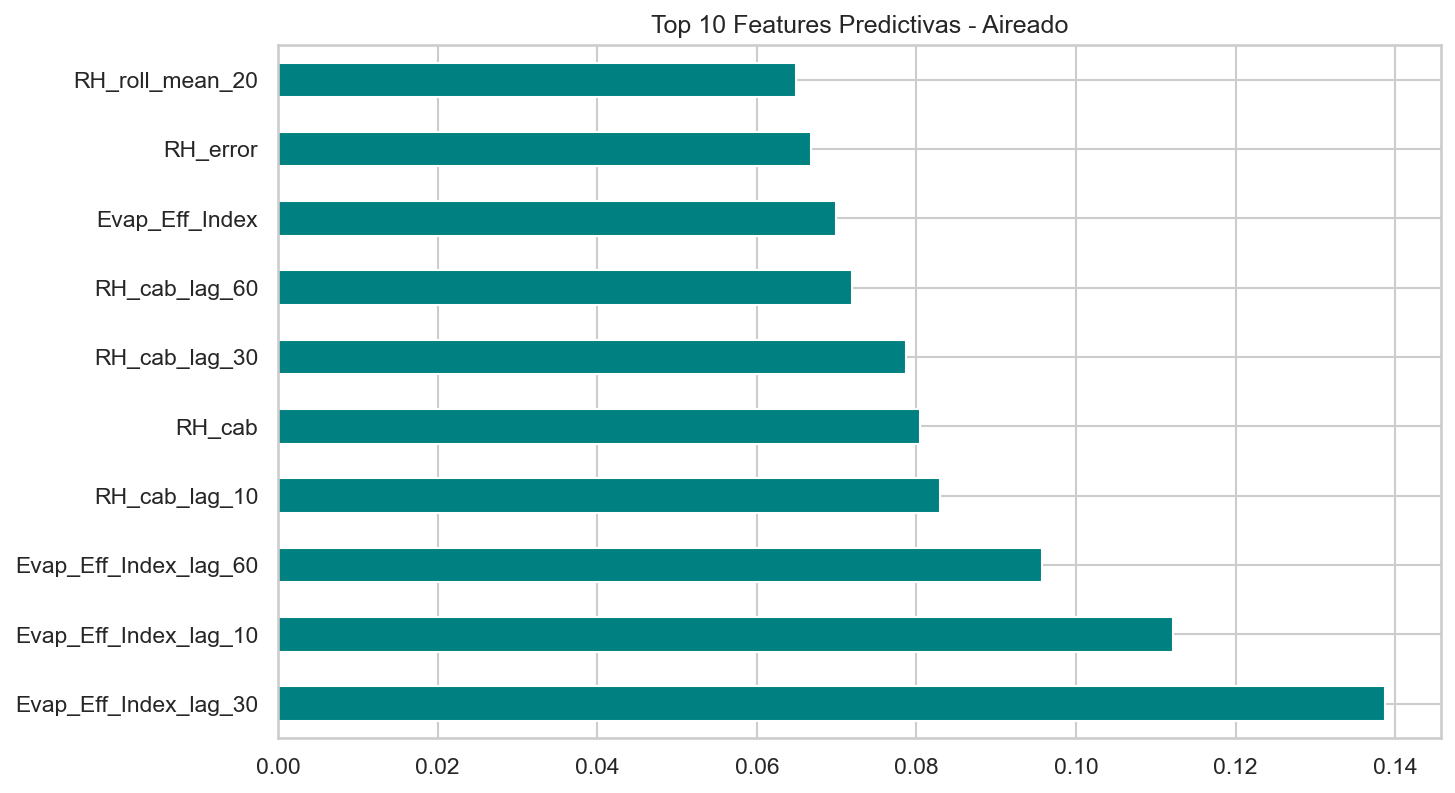

In [31]:
# Visualización de Features más importantes para el secado
importances = pd.Series(rf_aireado.feature_importances_, index=features).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='teal')
plt.title("Top 10 Features Predictivas - Aireado")
plt.show()

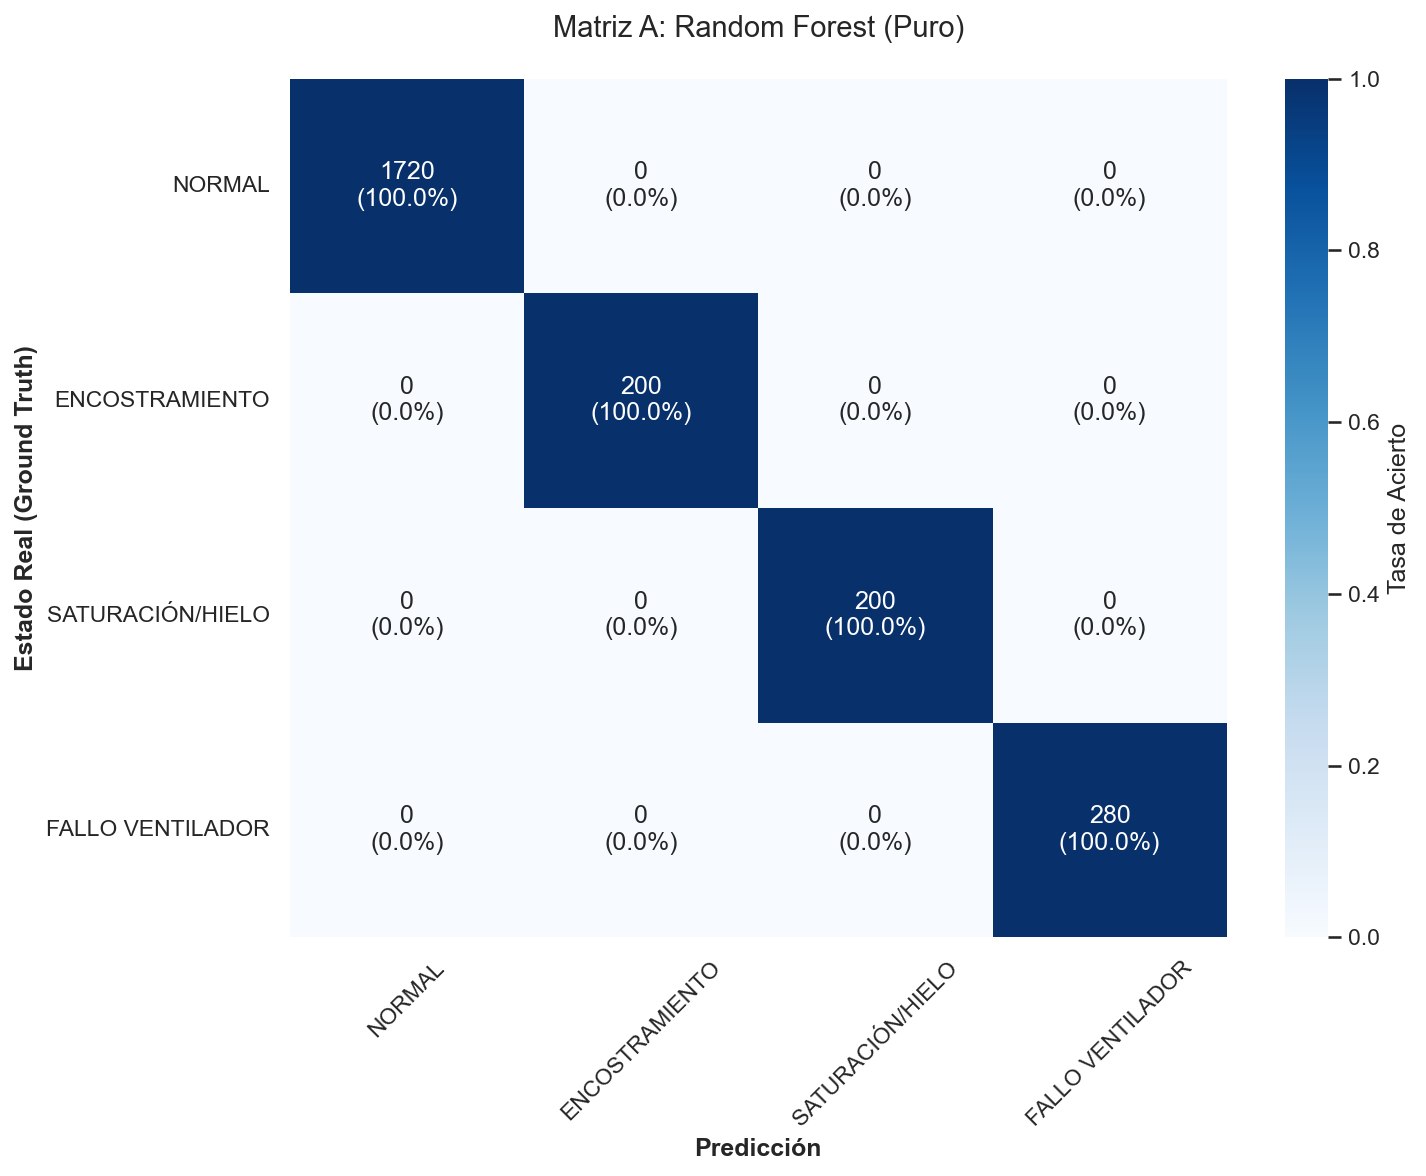


--- MÉTRICAS: Matriz A: Random Forest (Puro) ---
                  precision    recall  f1-score   support

          NORMAL       1.00      1.00      1.00      1720
  ENCOSTRAMIENTO       1.00      1.00      1.00       200
SATURACIÓN/HIELO       1.00      1.00      1.00       200
FALLO VENTILADOR       1.00      1.00      1.00       280

        accuracy                           1.00      2400
       macro avg       1.00      1.00      1.00      2400
    weighted avg       1.00      1.00      1.00      2400



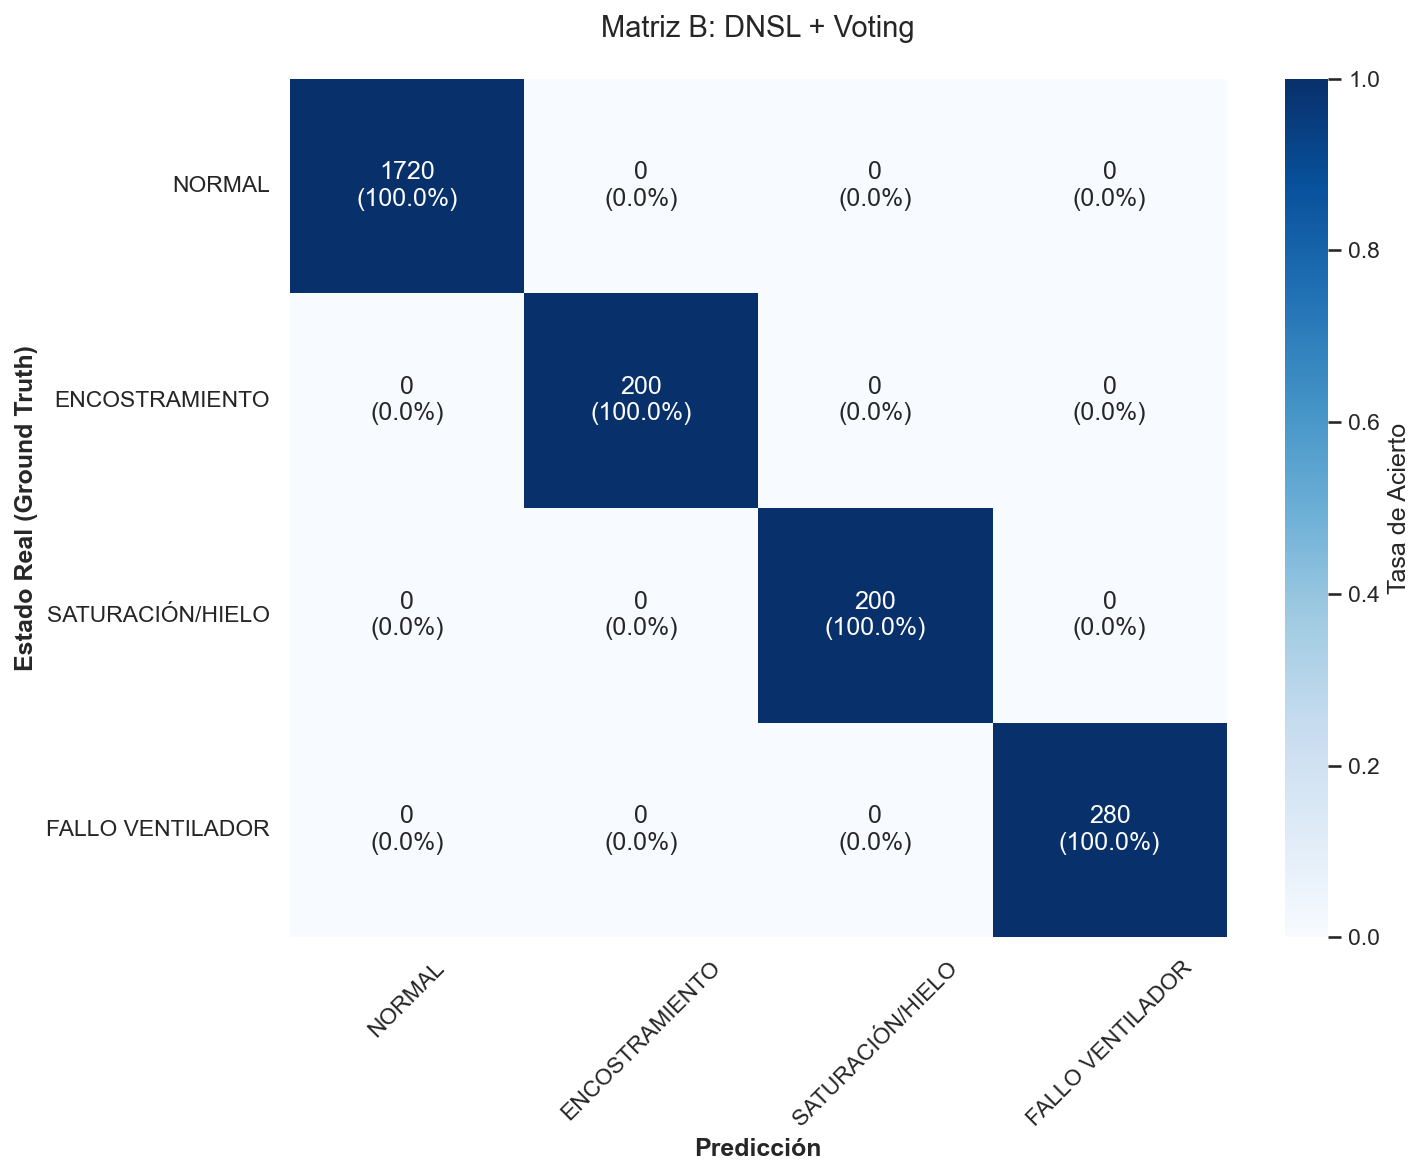


--- MÉTRICAS: Matriz B: DNSL + Voting ---
                  precision    recall  f1-score   support

          NORMAL       1.00      1.00      1.00      1720
  ENCOSTRAMIENTO       1.00      1.00      1.00       200
SATURACIÓN/HIELO       1.00      1.00      1.00       200
FALLO VENTILADOR       1.00      1.00      1.00       280

        accuracy                           1.00      2400
       macro avg       1.00      1.00      1.00      2400
    weighted avg       1.00      1.00      1.00      2400



In [32]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns



def plot_advanced_confusion_matrix(y_true, y_pred, mapping, title):
    """
    Genera una matriz de confusión detallada a partir de etiquetas reales y predichas.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Calcular porcentajes (Normalización por filas/True labels)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Extraer nombres de las etiquetas
    labels = [mapping[i] for i in sorted(mapping.keys())]
    
    plt.figure(figsize=(10, 8))
    
    # Anotaciones: valor absoluto + porcentaje
    annotations = np.array([f"{val}\n({perc:.1%})" for val, perc in zip(cm.flatten(), cm_perc.flatten())]).reshape(cm.shape)
    
    sns.heatmap(cm_perc, annot=annotations, fmt="", cmap='Blues', 
                xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Tasa de Acierto'})
    
    plt.xlabel("Predicción", fontsize=12, fontweight='bold')
    plt.ylabel("Estado Real (Ground Truth)", fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, pad=20)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Métricas
    print(f"\n--- MÉTRICAS: {title} ---")
    print(classification_report(y_true, y_pred, target_names=labels))

    
# Ejecución
# Matriz A: El Random Forest por sí solo
plot_advanced_confusion_matrix(y_test, y_pred_pure, target_mapping, "Matriz A: Random Forest (Puro)")
# (Sugerencia: Cambia el título interno de la función a "Matriz A: Random Forest (Puro)")

# Matriz B: El sistema experto integrado
plot_advanced_confusion_matrix(y_test, y_pred_final, target_mapping, "Matriz B: DNSL + Voting")
# (Sugerencia: Cambia el título interno a "Matriz B: DNSL + Voting Consenso")

=== COMPARATIVA DE ROBUSTEZ: EFECTO DEL VOTO POR RUN ===
            Métrica Modelo Puro (Fila a Fila) Modelo con Voto por Run
           Accuracy                    0.9379                  1.0000
F1-Score (Weighted)                    0.9415                  1.0000


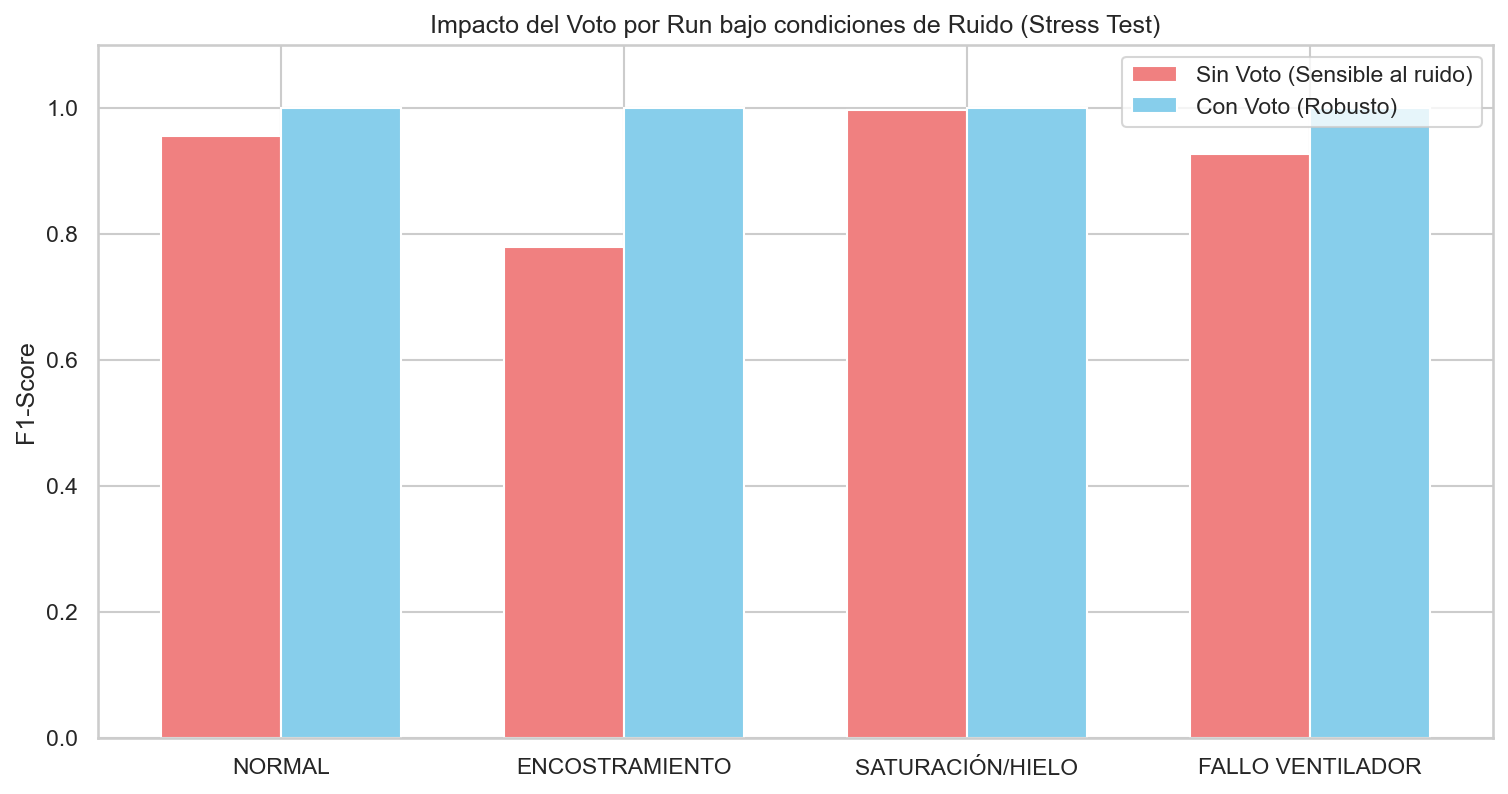

In [33]:
from sklearn.metrics import accuracy_score, f1_score

def compare_voting_robustness(y_true, y_pred_pure, y_pred_voted, target_names):
    # Calcular métricas para ambos
    acc_pure = accuracy_score(y_true, y_pred_pure)
    acc_voted = accuracy_score(y_true, y_pred_voted)
    f1_pure = f1_score(y_true, y_pred_pure, average='weighted')
    f1_voted = f1_score(y_true, y_pred_voted, average='weighted')
    
    # Crear tabla comparativa
    results = pd.DataFrame({
        'Métrica': ['Accuracy', 'F1-Score (Weighted)'],
        'Modelo Puro (Fila a Fila)': [f"{acc_pure:.4f}", f"{f1_pure:.4f}"],
        'Modelo con Voto por Run': [f"{acc_voted:.4f}", f"{f1_voted:.4f}"]
    })
    
    print("=== COMPARATIVA DE ROBUSTEZ: EFECTO DEL VOTO POR RUN ===")
    print(results.to_string(index=False))
    
    # Visualización de la degradación por clase
    report_pure = classification_report(y_true, y_pred_pure, target_names=target_names, output_dict=True)
    report_voted = classification_report(y_true, y_pred_voted, target_names=target_names, output_dict=True)
    
    f1_by_class_pure = [report_pure[name]['f1-score'] for name in target_names]
    f1_by_class_voted = [report_voted[name]['f1-score'] for name in target_names]
    
    x = np.arange(len(target_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, f1_by_class_pure, width, label='Sin Voto (Sensible al ruido)', color='lightcoral')
    ax.bar(x + width/2, f1_by_class_voted, width, label='Con Voto (Robusto)', color='skyblue')
    
    ax.set_ylabel('F1-Score')
    ax.set_title('Impacto del Voto por Run bajo condiciones de Ruido (Stress Test)')
    ax.set_xticks(x)
    ax.set_xticklabels(target_names)
    ax.legend(loc = 'best')
    ax.set_ylim(0, 1.1)
    
    plt.show()

# Ejecutar la comparativa 
compare_voting_robustness(
    y_test, 
    y_pred_noisy, 
    y_voted_noisy, 
    target_names=list(target_mapping.values())
)

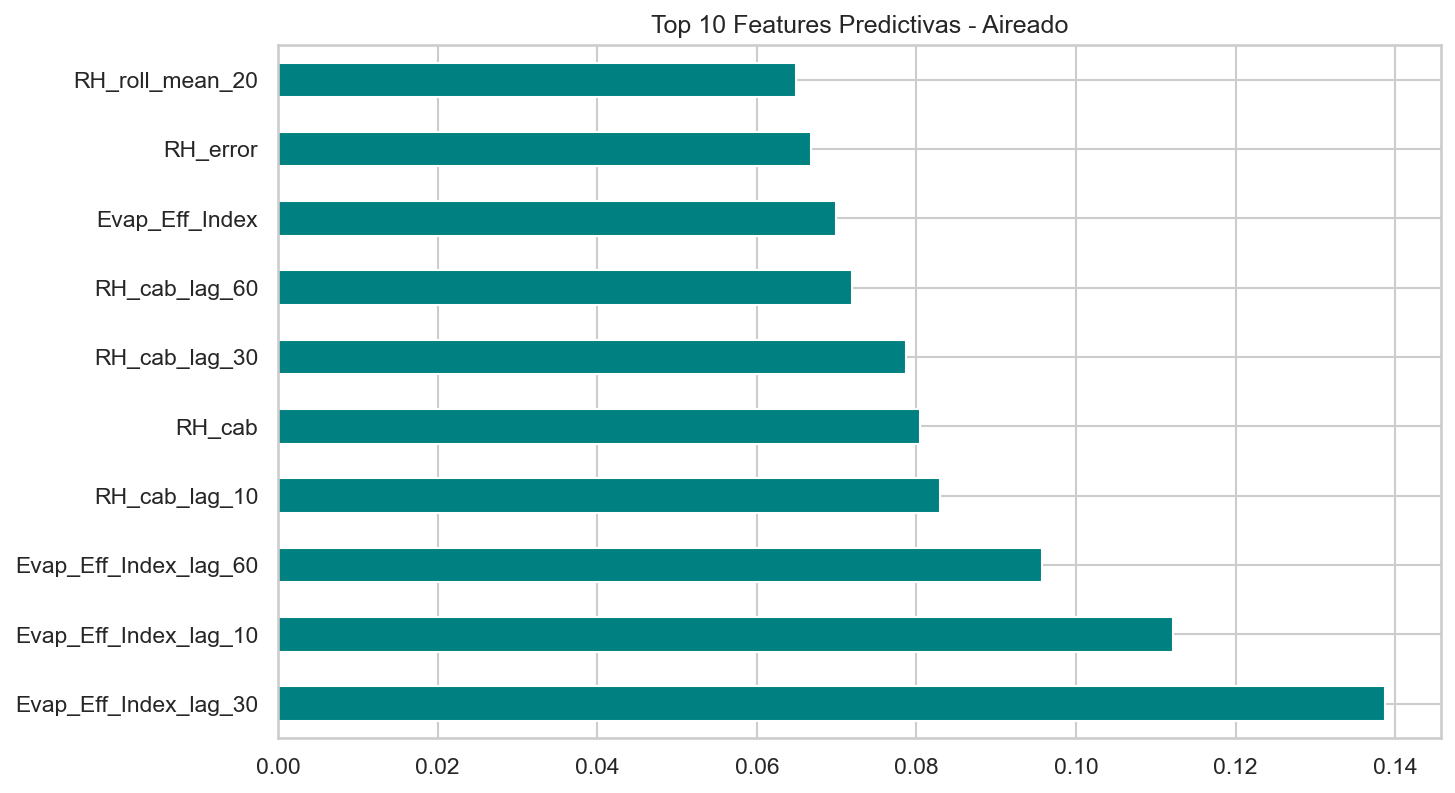

In [34]:
#Feature importances
importances = pd.Series(rf_aireado.feature_importances_, index=features).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='teal')
plt.title("Top 10 Features Predictivas - Aireado")
plt.show()